Initial Data:
   id             timestamp                       platform  duration_ms  \
0   1  2014-07-13T23:56:17Z  WebPlayer (websocket RFC6455)            0   
1   2  2014-07-13T23:56:28Z  WebPlayer (websocket RFC6455)            0   
2   3  2014-07-13T23:56:32Z  WebPlayer (websocket RFC6455)         2413   
3   4  2014-07-13T23:59:00Z  WebPlayer (websocket RFC6455)       145893   
4   5  2014-07-13T23:59:06Z  WebPlayer (websocket RFC6455)         4430   

         track_name             artist          album  \
0      Did It Hurt?  Never Shout Never  Me and My Uke   
1      Did It Hurt?  Never Shout Never  Me and My Uke   
2  Your Biggest Fan  Never Shout Never  Me and My Uke   
3           Trouble  Never Shout Never  Me and My Uke   
4      Did It Hurt?  Never Shout Never  Me and My Uke   

                              track_uri reason_start reason_end  shuffle  \
0  spotify:track:6QoXmepZzCJUBv5Ghwmfn9      playbtn    playbtn        0   
1  spotify:track:6QoXmepZzCJUBv5Ghwmfn9 

/tmp/ipykernel_23267/2318597647.py:33: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['duration_ms'].fillna(df['duration_ms'].median(), inplace=True)



Feature Data:
    listening_frequency  avg_duration  skip_rate  Afternoon  Evening  Morning  \
id                                                                              
1                     1           0.0        0.0          0        0        0   
2                     1           0.0        0.0          0        0        0   
3                     1        2413.0        0.0          0        0        0   
4                     1      145893.0        0.0          0        0        0   
5                     1        4430.0        0.0          0        0        0   

    Night  
id         
1       1  
2       1  
3       1  
4       1  
5       1  

Clustered Data:
    listening_frequency  avg_duration  skip_rate  Afternoon  Evening  Morning  \
id                                                                              
1                     1           0.0        0.0          0        0        0   
2                     1           0.0        0.0          0        0     

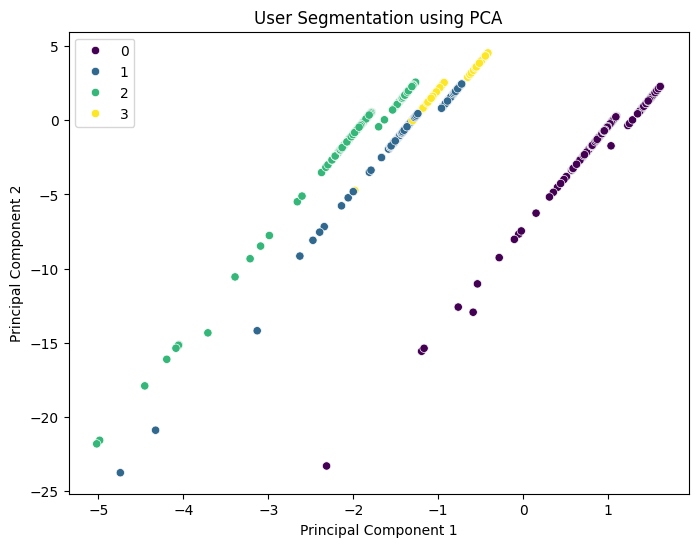


Cluster Summary:
         listening_frequency   avg_duration  skip_rate  Afternoon  Evening  \
cluster                                                                      
0                        1.0  126709.019012   0.124675        0.0      0.0   
1                        1.0  126787.361496   0.027239        1.0      0.0   
2                        1.0  134405.705437   0.068519        0.0      1.0   
3                        1.0   96831.448815   0.252886        0.0      0.0   

         Morning  Night      PCA1      PCA2  
cluster                                      
0            0.0    1.0  1.056958 -0.193293  
1            0.0    0.0 -1.329230 -0.215023  
2            0.0    0.0 -1.859196 -0.074162  
3            1.0    0.0 -0.879474  2.501719  

Project Completed Successfully ✅


In [ ]:
# ==============================
# MUSIC LISTENER SEGMENTATION
# ==============================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ==============================
# 1. LOAD DATA
# ==============================

# Replace with your dataset file
df = pd.read_csv("listening_history.csv")

print("Initial Data:")
print(df.head())

# ==============================
# 2. DATA PREPROCESSING
# ==============================

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Handle missing values (median for duration)
df['duration_ms'].fillna(df['duration_ms'].median(), inplace=True)

# Extract hour
df['hour'] = df['timestamp'].dt.hour

# ==============================
# 3. TIME SEGMENT CREATION
# ==============================

def get_time_segment(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['time_segment'] = df['hour'].apply(get_time_segment)

# ==============================
# 4. FEATURE ENGINEERING
# ==============================

# Listening frequency (count per user)
user_freq = df.groupby('id').size().rename('listening_frequency')

# Average duration
avg_duration = df.groupby('id')['duration_ms'].mean().rename('avg_duration')

# Skip rate
skip_rate = df.groupby('id')['skipped'].mean().rename('skip_rate')

# Time segment distribution
time_segment_counts = pd.crosstab(df['id'], df['time_segment'])

# Combine all features
features = pd.concat([user_freq, avg_duration, skip_rate, time_segment_counts], axis=1)

# Fill missing values
features.fillna(0, inplace=True)

print("\nFeature Data:")
print(features.head())

# ==============================
# 5. NORMALIZATION
# ==============================

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# ==============================
# 6. K-MEANS CLUSTERING
# ==============================

k = 4   # From your presentation
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

features['cluster'] = kmeans.fit_predict(scaled_features)

print("\nClustered Data:")
print(features.head())

# ==============================
# 7. PCA FOR VISUALIZATION
# ==============================

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)

features['PCA1'] = pca_result[:, 0]
features['PCA2'] = pca_result[:, 1]

# ==============================
# 8. VISUALIZATION
# ==============================

plt.figure(figsize=(8,6))
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='cluster',
    palette='viridis',
    data=features
)

plt.title("User Segmentation using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

# ==============================
# 9. CLUSTER ANALYSIS
# ==============================

cluster_summary = features.groupby('cluster').mean()
print("\nCluster Summary:")
print(cluster_summary)

# ==============================
# 10. SAVE OUTPUT
# ==============================

features.to_csv("segmented_users.csv")

print("\nProject Completed Successfully ✅")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving listening_history.csv to listening_history.csv
